# IMPORTACIÓN DE LIBRERÍAS

In [78]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

# LECTURA DE DATOS

In [79]:
df_dengue = pd.read_csv('datos_abiertos_vigilancia_dengue_2000_2024.csv', sep=';')

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_22948\1835617851.py:1: DtypeWarning: Columns (0: localcod) have mixed types. Specify dtype option on import or set low_memory=False.
  df_dengue = pd.read_csv('datos_abiertos_vigilancia_dengue_2000_2024.csv', sep=';')


# EDA

In [80]:
df_dengue.head()

,departamento,provincia,distrito,localidad,enfermedad,ano,semana,diagnostic,diresa,ubigeo,localcod,edad,tipo_edad,sexo
0,LORETO,ALTO AMAZONAS,YURIMAGUAS,000101,DENGUE SIN SIGNOS DE ALARMA,2000,1,A97.0,16.0,160201,NaN,58,A,M
1,LORETO,ALTO AMAZONAS,YURIMAGUAS,000101,DENGUE SIN SIGNOS DE ALARMA,2000,1,A97.0,16.0,160201,NaN,44,A,F
2,LORETO,ALTO AMAZONAS,YURIMAGUAS,BARRIO MORALILLOS,DENGUE SIN SIGNOS DE ALARMA,2000,1,A97.0,16.0,160201,NaN,21,A,F
3,LORETO,MAYNAS,IQUITOS,005902,DENGUE SIN SIGNOS DE ALARMA,2000,1,A97.0,16.0,160101,NaN,74,A,M
4,LORETO,MAYNAS,IQUITOS,CARDOZO,DENGUE SIN SIGNOS DE ALARMA,2000,1,A97.0,16.0,160101,NaN,42,A,F


In [81]:
df_dengue.info()

<class 'pandas.DataFrame'>
RangeIndex: 1029421 entries, 0 to 1029420
Data columns (total 14 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   departamento  1029421 non-null  str    
 1   provincia     1029421 non-null  str    
 2   distrito      1029421 non-null  str    
 3   localidad     906823 non-null   str    
 4   enfermedad    1029421 non-null  str    
 5   ano           1029421 non-null  int64  
 6   semana        1029421 non-null  int64  
 7   diagnostic    1029421 non-null  str    
 8   diresa        1029398 non-null  float64
 9   ubigeo        1029421 non-null  int64  
 10  localcod      880780 non-null   object 
 11  edad          1029421 non-null  int64  
 12  tipo_edad     1029421 non-null  str    
 13  sexo          1029421 non-null  str    
dtypes: float64(1), int64(4), object(1), str(8)
memory usage: 110.0+ MB


In [82]:
# Resumen de columnas de texto
df_dengue.describe(include=['O', 'string'])

,departamento,provincia,distrito,localidad,enfermedad,diagnostic,localcod,tipo_edad,sexo
count,1029421,1029421,1029421,906823,1029421,1029421,880780,1029421,1029421
unique,23,124,625,10131,3,3,13123,3,2
top,PIURA,PIURA,PIURA,IQUITOS,DENGUE SIN SIGNOS DE ALARMA,A97.0,0,A,F
freq,237961,113248,39782,20873,915243,915243,21496,1022720,553677


In [83]:
# Muestra las categorías de la enfermedad y qué porcentaje representa cada una
print(df_dengue['enfermedad'].value_counts(normalize=True) * 100)

print("\n--- Diagnósticos ---")
print(df_dengue['diagnostic'].value_counts(normalize=True) * 100)

enfermedad
DENGUE SIN SIGNOS DE ALARMA    88.908522
DENGUE CON SIGNOS DE ALARMA    10.701744
DENGUE GRAVE                    0.389734
Name: proportion, dtype: float64

--- Diagnósticos ---
diagnostic
A97.0    88.908522
A97.1    10.701744
A97.2     0.389734
Name: proportion, dtype: float64


In [84]:
# Conteo total de nulos por columna
print("--- Cantidad de Nulos ---")
print(df_dengue.isnull().sum())

# Porcentaje de nulos por columna
print("\n--- Porcentaje de Nulos (%) ---")
print(round(df_dengue.isnull().sum() / len(df_dengue) * 100, 2))

--- Cantidad de Nulos ---
departamento         0
provincia            0
distrito             0
localidad       122598
enfermedad           0
ano                  0
semana               0
diagnostic           0
diresa              23
ubigeo               0
localcod        148641
edad                 0
tipo_edad            0
sexo                 0
dtype: int64

--- Porcentaje de Nulos (%) ---
departamento     0.00
provincia        0.00
distrito         0.00
localidad       11.91
enfermedad       0.00
ano              0.00
semana           0.00
diagnostic       0.00
diresa           0.00
ubigeo           0.00
localcod        14.44
edad             0.00
tipo_edad        0.00
sexo             0.00
dtype: float64


In [85]:
# Ver qué categorías existen en 'tipo_edad' y cuántos pacientes hay en cada una
print("--- Tipos de Edad ---")
print(df_dengue['tipo_edad'].value_counts())

--- Tipos de Edad ---
tipo_edad
A    1022720
M       6377
D        324
Name: count, dtype: int64


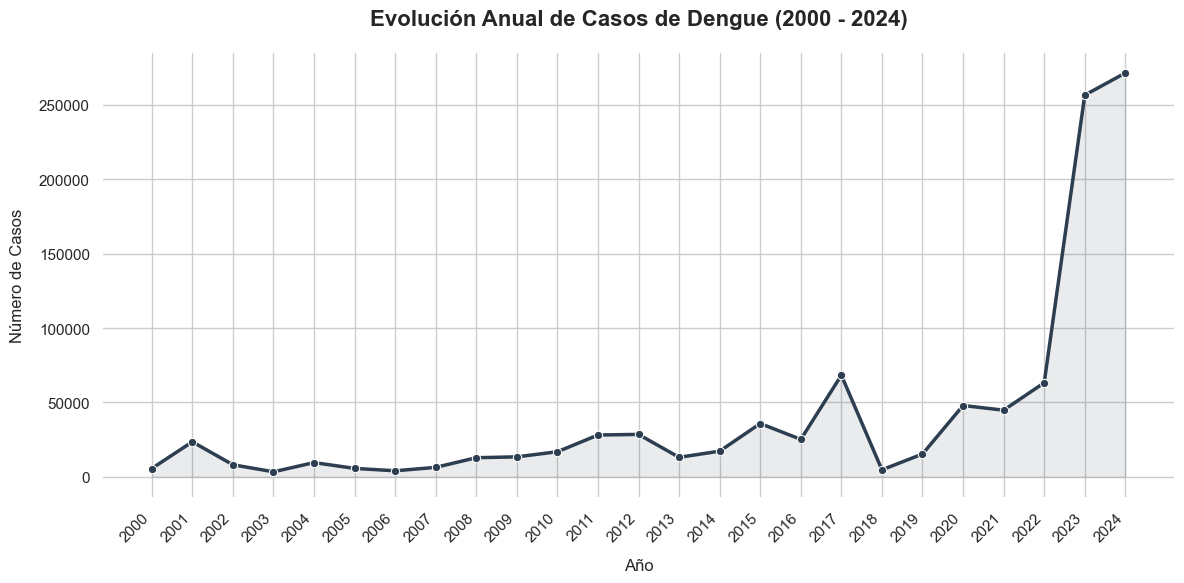

In [86]:
# Agrupamos los casos por año (por si no guardaste la variable anterior)
casos_por_ano = df_dengue['ano'].value_counts().sort_index()

# Configuración de estilo limpio y profesional
sns.set_theme(style="whitegrid")

# 1. Dimensiones de la figura (la hacemos un poco más ancha)
plt.figure(figsize=(12, 6))

# 2. Cambiamos a gráfico de líneas (ideal para series temporales)
sns.lineplot(
    x=casos_por_ano.index, 
    y=casos_por_ano.values, 
    marker="o",          # Añade un punto en cada año para identificarlo bien
    linewidth=2.5,       # Línea más gruesa y visible
    color="#2c3e50"      # Un color elegante (azul oscuro/grisáceo)
)

# 3. Sombreado bajo la línea (opcional, le da un toque analítico muy pro)
plt.fill_between(casos_por_ano.index, casos_por_ano.values, alpha=0.1, color="#2c3e50")

# 4. SOLUCIÓN AL EJE X: Rotamos las etiquetas 45 grados y las alineamos a la derecha
plt.xticks(ticks=casos_por_ano.index, labels=casos_por_ano.index, rotation=45, ha='right')

# 5. Títulos y etiquetas con mejor espaciado (pad)
plt.title("Evolución Anual de Casos de Dengue (2000 - 2024)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Año", fontsize=12, labelpad=10)
plt.ylabel("Número de Casos", fontsize=12, labelpad=10)

# Reducimos líneas innecesarias del marco
sns.despine(left=True, bottom=True)

# Ajuste perfecto para que no se corte la rotación de los años
plt.tight_layout()

plt.show()

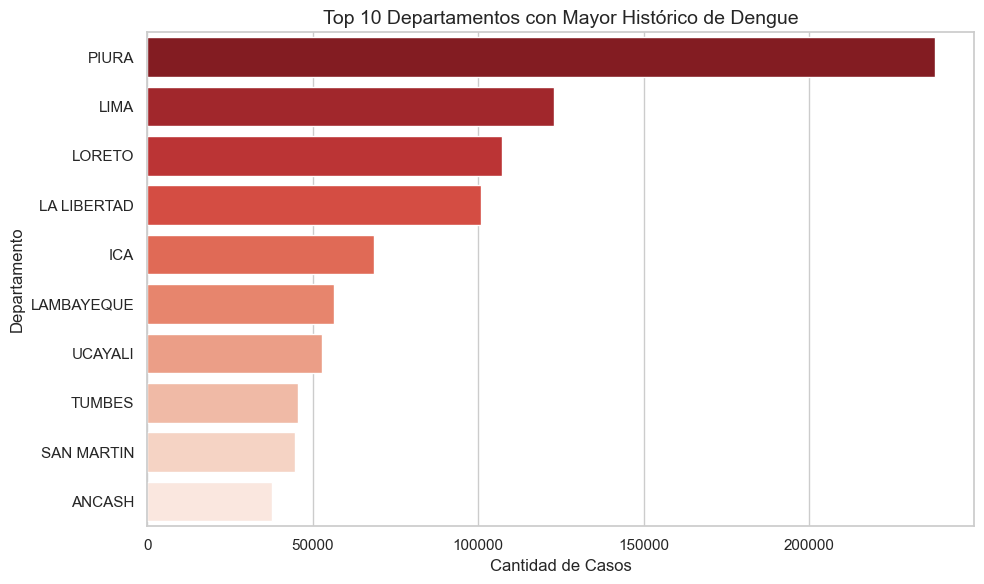

departamento
PIURA            23.116004
LIMA             11.934282
LORETO           10.401381
LA LIBERTAD       9.792884
ICA               6.665883
LAMBAYEQUE        5.477157
UCAYALI           5.111708
TUMBES            4.417143
SAN MARTIN        4.324567
ANCASH            3.658464
MADRE DE DIOS     3.197914
CAJAMARCA         2.886186
JUNIN             2.536377
AMAZONAS          1.632471
CUSCO             1.477530
HUANUCO           1.177264
AYACUCHO          0.966174
CALLAO            0.790541
PASCO             0.369334
PUNO              0.062851
AREQUIPA          0.002720
APURIMAC          0.001069
MOQUEGUA          0.000097
Name: proportion, dtype: float64


In [87]:
# GEOGRAFÍA
# Configuración visual
sns.set_theme(style="whitegrid")

# Calculamos los casos por departamento
casos_dep = df_dengue['departamento'].value_counts()

# Gráfico de barras horizontales para los 10 departamentos con más casos
plt.figure(figsize=(10, 6))
sns.barplot(x=casos_dep.values[:10], y=casos_dep.index[:10], hue=casos_dep.index[:10], palette="Reds_r",legend=False)
plt.title('Top 10 Departamentos con Mayor Histórico de Dengue', fontsize=14)
plt.xlabel('Cantidad de Casos')
plt.ylabel('Departamento')
plt.tight_layout()
plt.show()

# Para ver la lista completa con porcentajes en texto
print(df_dengue['departamento'].value_counts(normalize=True) * 100)

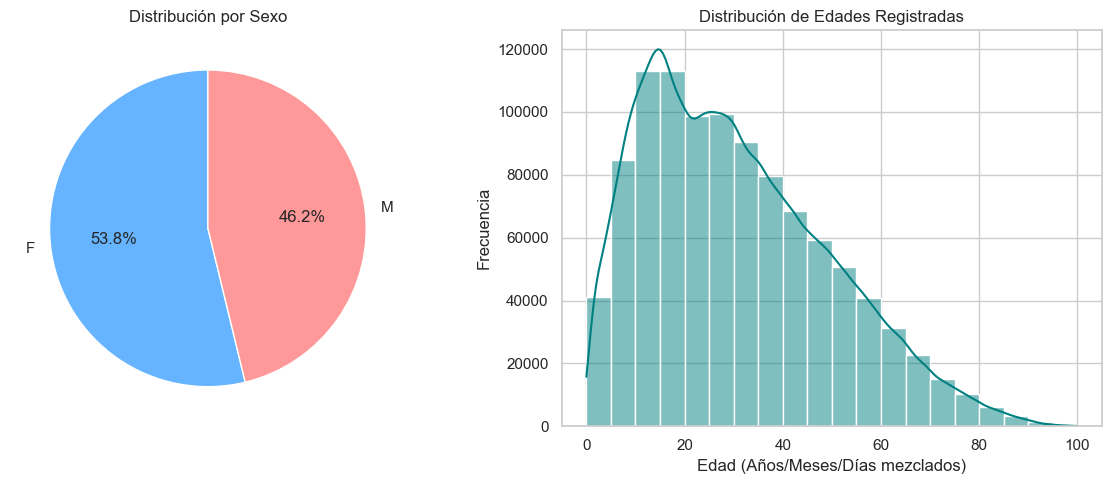


--- Categorías en Sexo ---
sexo
F    553677
M    475744
Name: count, dtype: int64


In [88]:
# DEMOGRAFÍA
# 1. Análisis de Sexo
plt.figure(figsize=(12, 5))

# Subgráfico 1: Sexo
plt.subplot(1, 2, 1)
sexo_counts = df_dengue['sexo'].value_counts()
plt.pie(sexo_counts.values, labels=sexo_counts.index, autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90)
plt.title('Distribución por Sexo')

# Subgráfico 2: Histograma de Edad bruta
plt.subplot(1, 2, 2)
# Filtramos edades ilógicas (a veces hay errores de tipeo con edades > 120)
sns.histplot(data=df_dengue[df_dengue['edad'] <= 100], x='edad', bins=20, color='teal', kde=True)
plt.title('Distribución de Edades Registradas')
plt.xlabel('Edad (Años/Meses/Días mezclados)')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Verificamos si hay algún error de registro en "sexo" (letras raras)
print("\n--- Categorías en Sexo ---")
print(df_dengue['sexo'].value_counts())

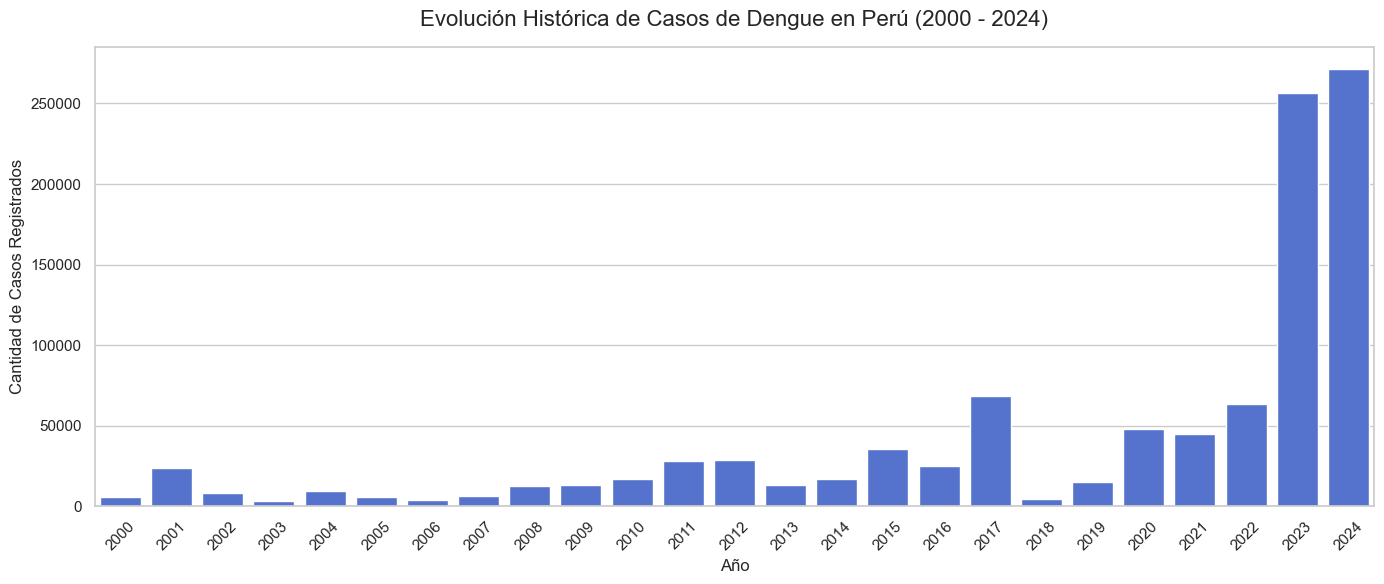

In [89]:
# Agrupamos los casos por año (por si no guardaste la variable anterior)
casos_por_ano = df_dengue['ano'].value_counts().sort_index()

# Configuramos el estilo del gráfico para que se vea profesional
sns.set_theme(style="whitegrid")

# Creamos la figura y le damos tamaño
plt.figure(figsize=(14, 6))

# Creamos un gráfico de barras
sns.barplot(x=casos_por_ano.index, y=casos_por_ano.values, color="royalblue")

# Añadimos títulos y etiquetas
plt.title('Evolución Histórica de Casos de Dengue en Perú (2000 - 2024)', fontsize=16, pad=15)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Cantidad de Casos Registrados', fontsize=12)

# Inclinamos los años en el eje X para que no se superpongan
plt.xticks(rotation=45)

# Ajustamos el diseño y mostramos el gráfico
plt.tight_layout()
plt.show()

In [90]:
# Contamos cuántos casos hubo por cada año y los ordenamos cronológicamente
casos_por_ano = df_dengue['ano'].value_counts().sort_index()

print("--- Casos de Dengue por Año ---")
print(casos_por_ano)

--- Casos de Dengue por Año ---
ano
2000      5557
2001     23526
2002      8086
2003      3349
2004      9547
2005      5640
2006      4022
2007      6344
2008     12824
2009     13407
2010     16842
2011     28084
2012     28505
2013     13091
2014     17234
2015     35816
2016     25160
2017     68290
2018      4698
2019     15287
2020     47932
2021     44791
2022     63217
2023    256641
2024    271531
Name: count, dtype: int64


In [91]:
# 3. Análisis de Variables Demográficas
print("\n--- Distribución de Sexo ---")
print(df_dengue['sexo'].value_counts(dropna=False))

print("\n--- Distribución de Tipo de Edad ---")
print(df_dengue['tipo_edad'].value_counts(dropna=False))


--- Distribución de Sexo ---
sexo
F    553677
M    475744
Name: count, dtype: int64

--- Distribución de Tipo de Edad ---
tipo_edad
A    1022720
M       6377
D        324
Name: count, dtype: int64


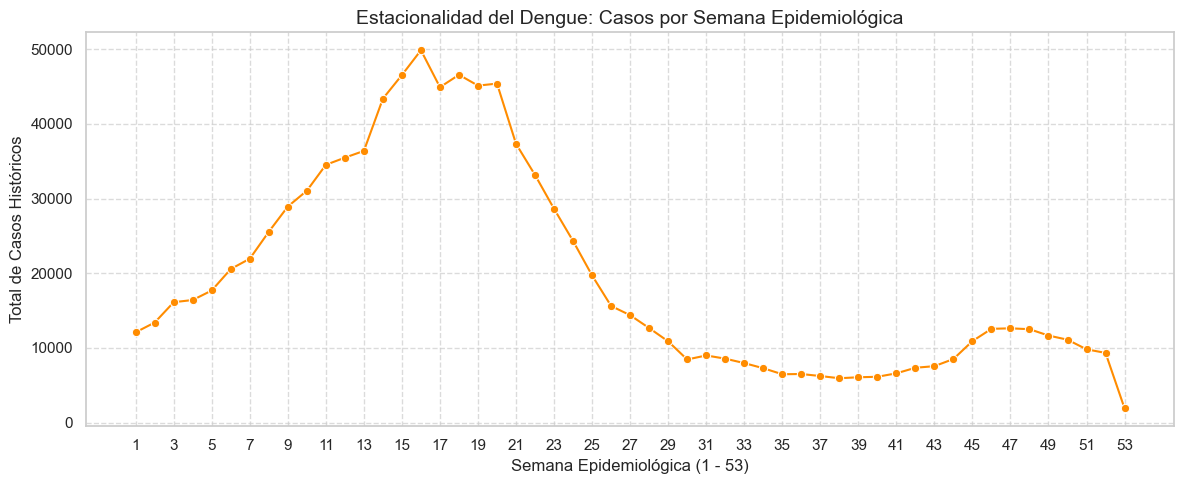

--- Tipos de Enfermedad Registrados ---
enfermedad
DENGUE SIN SIGNOS DE ALARMA    915243
DENGUE CON SIGNOS DE ALARMA    110166
DENGUE GRAVE                     4012
Name: count, dtype: int64

--- Top 5 Códigos de Diagnóstico (CIE-10) ---
diagnostic
A97.0    915243
A97.1    110166
A97.2      4012
Name: count, dtype: int64

--- Top 10 Departamentos con Mayor Carga de Dengue ---
departamento
PIURA          237961
LIMA           122854
LORETO         107074
LA LIBERTAD    100810
ICA             68620
LAMBAYEQUE      56383
UCAYALI         52621
TUMBES          45471
SAN MARTIN      44518
ANCASH          37661
Name: count, dtype: int64

--- Edades Extremas por Tipo de Edad ---
           min       max        mean    count
tipo_edad                                    
A            0  71963641  148.530006  1022720
D            1        30   11.200617      324
M            1        58    7.262035     6377


In [92]:
# ESTACIONALIDAD
# Contamos los casos por cada una de las 52 semanas
casos_semana = df_dengue['semana'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.lineplot(x=casos_semana.index, y=casos_semana.values, marker="o", color="darkorange")
plt.title('Estacionalidad del Dengue: Casos por Semana Epidemiológica', fontsize=14)
plt.xlabel('Semana Epidemiológica (1 - 53)')
plt.ylabel('Total de Casos Históricos')
plt.xticks(range(1, 54, 2)) # Mostrar números de 2 en 2 para no amontonar
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 2. Análisis Clínico: ¿Qué tipo de Dengue predomina?
print("--- Tipos de Enfermedad Registrados ---")
print(df_dengue['enfermedad'].value_counts())

print("\n--- Top 5 Códigos de Diagnóstico (CIE-10) ---")
print(df_dengue['diagnostic'].value_counts().head(5))

# 3. Análisis Geográfico: Top de Departamentos con más casos
print("\n--- Top 10 Departamentos con Mayor Carga de Dengue ---")
print(df_dengue['departamento'].value_counts().head(10))

# 4. Análisis de Consistencia en Edades
print("\n--- Edades Extremas por Tipo de Edad ---")
print(df_dengue.groupby('tipo_edad')['edad'].agg(['min', 'max', 'mean', 'count']))

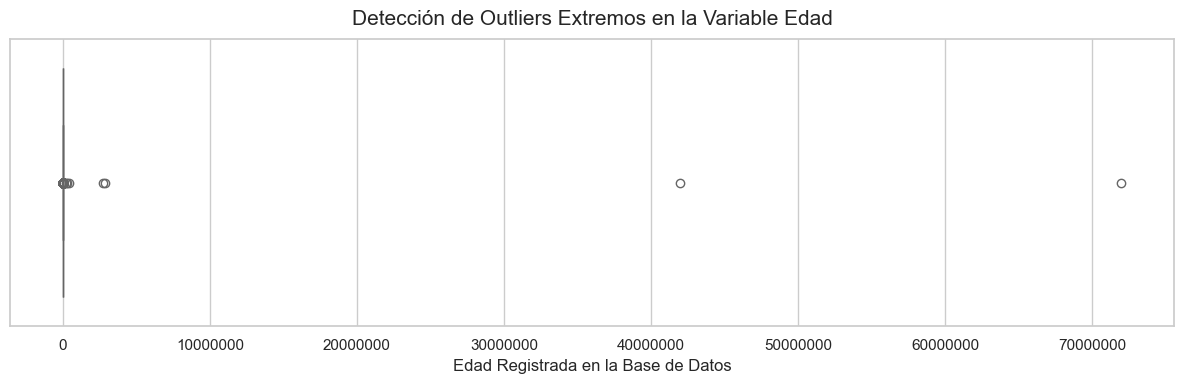

In [93]:
# 1. Configuramos el tamaño del lienzo (más ancho que alto para un boxplot horizontal)
plt.figure(figsize=(12, 4))

# 2. Generamos el diagrama de caja (boxplot)
# Al asignarlo al eje 'x', el gráfico será horizontal
sns.boxplot(data=df_dengue, x='edad', color='coral')

# 3. Personalizamos los textos
plt.title('Detección de Outliers Extremos en la Variable Edad', fontsize=15, pad=10)
plt.xlabel('Edad Registrada en la Base de Datos', fontsize=12)

# 4. TRUCO CLAVE: Forzamos a que Python no use notación científica (ej. 2e6) 
# para que puedas leer "2800000" tal cual en el eje.
plt.ticklabel_format(style='plain', axis='x')

# 5. Ajustamos y mostramos
plt.tight_layout()
plt.show()

In [94]:
# Ver cuántos registros tienen edades imposibles (mayores a 115 años)
edades_feas = df_dengue[(df_dengue['tipo_edad'] == 'A') & (df_dengue['edad'] > 117)]
print(f"Cantidad de filas con error de DNI en la edad: {len(edades_feas)}")
print(edades_feas[['departamento', 'ano', 'edad']].head())

Cantidad de filas con error de DNI en la edad: 12
       departamento   ano     edad
266266        PIURA  2017      814
278627        PIURA  2017  2846395
284113        PIURA  2017     6161
284469        PIURA  2017  2692587
285824        PIURA  2017      330


--- Límites Temporales Extraños ---
Años registrados: [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Semanas detectadas fuera del rango 1-53: []

--- Valores únicos exactos (para detectar espacios o errores) ---
Valores en Sexo: <StringArray>
['M', 'F']
Length: 2, dtype: str
Cantidad de Departamentos únicos detectados: 23

--- Longitud de los códigos de Ubigeo ---
ubigeo_str
6    911911
5    117510
Name: count, dtype: int64


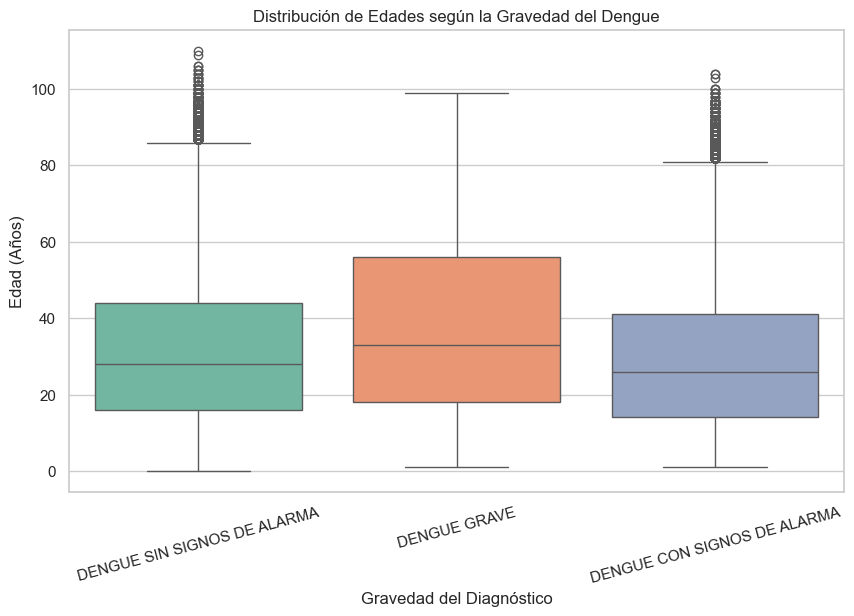

In [95]:
# 1. Buscar semanas o años fuera de la realidad
print("--- Límites Temporales Extraños ---")
print("Años registrados:", sorted(df_dengue['ano'].unique()))
semanas_raras = df_dengue[~df_dengue['semana'].between(1, 53)]['semana'].unique()
print("Semanas detectadas fuera del rango 1-53:", semanas_raras)

# 2. Buscar caracteres ocultos o valores raros en Sexo y Departamento
print("\n--- Valores únicos exactos (para detectar espacios o errores) ---")
print("Valores en Sexo:", df_dengue['sexo'].unique())
print("Cantidad de Departamentos únicos detectados:", df_dengue['departamento'].nunique())

# 3. Análisis de Ubigeos deformados (longitud del número)
df_dengue['ubigeo_str'] = df_dengue['ubigeo'].astype(str)
print("\n--- Longitud de los códigos de Ubigeo ---")
print(df_dengue['ubigeo_str'].str.len().value_counts())

# 4. EDA BIVARIADO: ¿Cómo se relaciona la EDAD (limpia) con la ENFERMEDAD?
# Creamos un dataframe temporal filtrando las 12 edades locas para no romper el gráfico
df_limpio_edad = df_dengue[(df_dengue['tipo_edad'] == 'A') & (df_dengue['edad'] <= 110)]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_limpio_edad, x='enfermedad', y='edad', hue='enfermedad', palette='Set2', legend=False)
plt.title('Distribución de Edades según la Gravedad del Dengue')
plt.xticks(rotation=15)
plt.xlabel('Gravedad del Diagnóstico')
plt.ylabel('Edad (Años)')
plt.show()

In [96]:
# Filtramos temporalmente las edades raras para que no afecten si usamos promedios
df_fil = df_dengue[(df_dengue['tipo_edad'] == 'A') & (df_dengue['edad'] <= 110)].copy()

print("==================================================================")
print("🎯 PREGUNTA 1: ¿La gravedad del dengue depende del sexo del paciente?")
print("==================================================================")
# Mostramos el porcentaje de severidad por cada sexo
tabla_sexo = pd.crosstab(df_fil['sexo'], df_fil['enfermedad'], normalize='index') * 100
print(tabla_sexo.round(2))

print("\n==================================================================")
print("🎯 PREGUNTA 2: ¿Cómo se expandió el dengue en Perú? (Línea de tiempo)")
print("==================================================================")
# Agrupamos por periodos de tiempo para ver qué departamentos dominaban antes y cuáles ahora
df_fil['periodo'] = pd.cut(df_fil['ano'], bins=[1999, 2010, 2020, 2024], labels=['2000-2010', '2011-2020', '2021-2024'])
for per in ['2000-2010', '2011-2020', '2021-2024']:
    print(f"\nTop 3 Departamentos en el periodo {per}:")
    print(df_fil[df_fil['periodo'] == per]['departamento'].value_counts().head(3))

print("\n==================================================================")
print("🎯 PREGUNTA 3: ¿Cuáles son las regiones con mayor PROPORCIÓN de Dengue Grave?")
print("==================================================================")
# Buscamos dónde es más peligroso enfermarse (porcentaje de casos graves por región)
tabla_region = pd.crosstab(df_fil['departamento'], df_fil['enfermedad'], normalize='index') * 100
# Ordenamos por la columna de DENGUE GRAVE para ver los más críticos
print(tabla_region.sort_values(by='DENGUE GRAVE', ascending=False)[['DENGUE GRAVE', 'DENGUE CON SIGNOS DE ALARMA']].head(5).round(2))

🎯 PREGUNTA 1: ¿La gravedad del dengue depende del sexo del paciente?
enfermedad  DENGUE CON SIGNOS DE ALARMA  DENGUE GRAVE  \
sexo                                                    
F                                 11.33          0.39   
M                                  9.90          0.38   

enfermedad  DENGUE SIN SIGNOS DE ALARMA  
sexo                                     
F                                 88.28  
M                                 89.72  

🎯 PREGUNTA 2: ¿Cómo se expandió el dengue en Perú? (Línea de tiempo)

Top 3 Departamentos en el periodo 2000-2010:
departamento
PIURA          31393
LORETO         24484
LA LIBERTAD    10313
Name: count, dtype: int64

Top 3 Departamentos en el periodo 2011-2020:
departamento
PIURA      78217
LORETO     52797
UCAYALI    27364
Name: count, dtype: int64

Top 3 Departamentos en el periodo 2021-2024:
departamento
PIURA          126783
LIMA           120533
LA LIBERTAD     76489
Name: count, dtype: int64

🎯 PREGUNTA 3: ¿Cuáles son la

🎯 DEEP DIVE 1: Severidad por Etapas de la Vida
enfermedad             DENGUE CON SIGNOS DE ALARMA  DENGUE GRAVE  \
grupo_edad                                                         
Niños (0-11)                                 12.37          0.33   
Adolescentes (12-17)                         11.59          0.31   
Jóvenes (18-29)                              10.77          0.33   
Adultos (30-59)                               9.58          0.34   
Adultos Mayores (60+)                        10.61          0.95   

enfermedad             DENGUE SIN SIGNOS DE ALARMA  
grupo_edad                                          
Niños (0-11)                                 87.30  
Adolescentes (12-17)                         88.11  
Jóvenes (18-29)                              88.90  
Adultos (30-59)                              90.07  
Adultos Mayores (60+)                        88.44  

🎯 DEEP DIVE 2: ¿Aumentó la gravedad en los últimos años (2023-2024)?
enfermedad  DENGUE CON SIGNOS DE AL

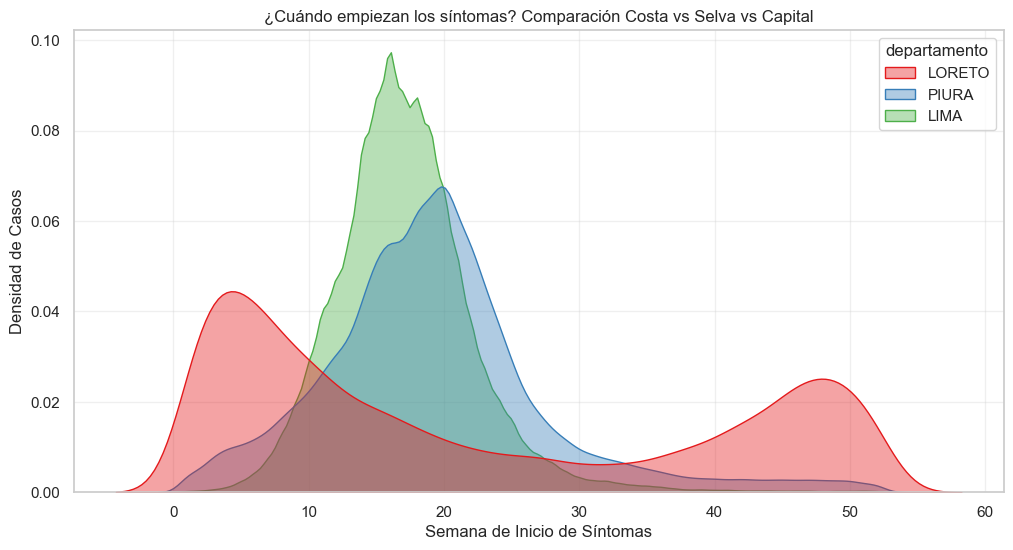

In [97]:
# Filtro de seguridad para edad
df_fil = df_dengue[(df_dengue['tipo_edad'] == 'A') & (df_dengue['edad'] <= 110)].copy()

print("==================================================================")
print("🎯 DEEP DIVE 1: Severidad por Etapas de la Vida")
print("==================================================================")
# Creamos grupos de edad epidemiológicos
limites = [0, 11, 17, 29, 59, 120]
etiquetas = ['Niños (0-11)', 'Adolescentes (12-17)', 'Jóvenes (18-29)', 'Adultos (30-59)', 'Adultos Mayores (60+)']
df_fil['grupo_edad'] = pd.cut(df_fil['edad'], bins=limites, labels=etiquetas)

tabla_edad = pd.crosstab(df_fil['grupo_edad'], df_fil['enfermedad'], normalize='index') * 100
print(tabla_edad.round(2))

print("\n==================================================================")
print("🎯 DEEP DIVE 2: ¿Aumentó la gravedad en los últimos años (2023-2024)?")
print("==================================================================")
# Analizamos los últimos 5 años para ver la tendencia de peligrosidad
ultimos_anos = df_fil[df_fil['ano'] >= 2020]
tabla_cronologica = pd.crosstab(ultimos_anos['ano'], ultimos_anos['enfermedad'], normalize='index') * 100
print(tabla_cronologica.round(2))

print("\n==================================================================")
print("🎯 DEEP DIVE 3: Estacionalidad Cruzada (Piura vs Loreto vs Lima)")
print("==================================================================")
# Filtramos los tres departamentos clave para comparar sus curvas de semanas
df_top3 = df_fil[df_fil['departamento'].isin(['PIURA', 'LORETO', 'LIMA'])]

plt.figure(figsize=(12, 6))
sns.kdeplot(data=df_top3, x='semana', hue='departamento', common_norm=False, fill=True, palette='Set1', alpha=0.4)
plt.title('¿Cuándo empiezan los síntomas? Comparación Costa vs Selva vs Capital')
plt.xlabel('Semana de Inicio de Síntomas')
plt.ylabel('Densidad de Casos')
plt.grid(True, alpha=0.3)
plt.show()

In [98]:
df_dengue.info()

<class 'pandas.DataFrame'>
RangeIndex: 1029421 entries, 0 to 1029420
Data columns (total 15 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   departamento  1029421 non-null  str    
 1   provincia     1029421 non-null  str    
 2   distrito      1029421 non-null  str    
 3   localidad     906823 non-null   str    
 4   enfermedad    1029421 non-null  str    
 5   ano           1029421 non-null  int64  
 6   semana        1029421 non-null  int64  
 7   diagnostic    1029421 non-null  str    
 8   diresa        1029398 non-null  float64
 9   ubigeo        1029421 non-null  int64  
 10  localcod      880780 non-null   object 
 11  edad          1029421 non-null  int64  
 12  tipo_edad     1029421 non-null  str    
 13  sexo          1029421 non-null  str    
 14  ubigeo_str    1029421 non-null  str    
dtypes: float64(1), int64(4), object(1), str(9)
memory usage: 117.8+ MB


# PREPROCESAMIENTO

df_base_limpio es el dataframe que posee el dataset con la limpieza universal como eliminación de columnas redundantes y columnas inecesarias, es el preprocesamiento universal que posee todas las "buenas prácticas" para la limpieza del dataset, sin importar qué modelo se va a entrenar con él 

Todos los modelos necesitan que el objetivo sea numérico, que el sexo sea binario y que los outliers de edad estén controlados.

In [99]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

In [100]:
# Creamos una copia de trabajo limpia
df_base_limpio = df_dengue.copy()

print(code_block_check := f"Dataset listo para procesar. Filas iniciales: {df_base_limpio.shape[0]}")

Dataset listo para procesar. Filas iniciales: 1029421


In [101]:
# ESTANDARIZACIÓN DE LA EDAD A AÑOS
# Convertimos a float para no perder precisión con los decimales
df_base_limpio['edad'] = df_base_limpio['edad'].astype(float)

# Transformamos meses a años (dividimos entre 12)
mask_meses = df_base_limpio['tipo_edad'] == 'M'
df_base_limpio.loc[mask_meses, 'edad'] = df_base_limpio.loc[mask_meses, 'edad'] / 12

# Transformamos días a años (dividimos entre 365)
mask_dias = df_base_limpio['tipo_edad'] == 'D'
df_base_limpio.loc[mask_dias, 'edad'] = df_base_limpio.loc[mask_dias, 'edad'] / 365

In [102]:
# Outliers de edad (Mediana)
mediana_edad = df_base_limpio.loc[df_base_limpio['edad'] <= 117, 'edad'].median()
df_base_limpio.loc[df_base_limpio['edad'] > 117, 'edad'] = mediana_edad

In [103]:
# Sexo (Binarización Directa para evitar multicolinealidad)
df_base_limpio['sexo'] = df_base_limpio['sexo'].map({'M': 0, 'F': 1})

In [104]:
# Enfermedad (Label Encoding Obligatorio)
le_target = LabelEncoder()
df_base_limpio['enfermedad'] = le_target.fit_transform(df_base_limpio['enfermedad'])

In [105]:
# ELIMINACIÓN DE COLUMNAS TÓXICAS Y REDUNDANTES
# Agregamos 'tipo_edad' a la lista negra
columnas_innecesarias = ['diagnostic', 'diresa', 'ubigeo', 'localidad', 'localcod', 'ubigeo_str', 'tipo_edad']

df_base_limpio = df_base_limpio.drop(columns=columnas_innecesarias)

print("Estandarización de edad y limpieza de columnas exitosa.")
print("Tamaño del dataset base final:", df_base_limpio.shape)
print("\nColumnas listas para iniciar los experimentos:")
print(df_base_limpio.columns.tolist())

Estandarización de edad y limpieza de columnas exitosa.
Tamaño del dataset base final: (1029421, 8)

Columnas listas para iniciar los experimentos:
['departamento', 'provincia', 'distrito', 'enfermedad', 'ano', 'semana', 'edad', 'sexo']


In [106]:
df_base_limpio.head()

,departamento,provincia,distrito,enfermedad,ano,semana,edad,sexo
0,LORETO,ALTO AMAZONAS,YURIMAGUAS,2,2000,1,58.0,0
1,LORETO,ALTO AMAZONAS,YURIMAGUAS,2,2000,1,44.0,1
2,LORETO,ALTO AMAZONAS,YURIMAGUAS,2,2000,1,21.0,1
3,LORETO,MAYNAS,IQUITOS,2,2000,1,74.0,0
4,LORETO,MAYNAS,IQUITOS,2,2000,1,42.0,1


In [107]:
# ==================================================================
# CELDA: Target Encoding para Variables Geográficas
# ==================================================================

print(f"Dimensiones antes del Target Encoding: {df_base_limpio.shape}")

# Definimos las columnas geográficas que vamos a transformar
columnas_geo = ['departamento', 'provincia', 'distrito']

# Aplicamos el Target Encoding iterando sobre cada columna
for col in columnas_geo:
    # Calculamos la media de 'enfermedad' para cada categoría de la columna
    target_mean = df_base_limpio.groupby(col)['enfermedad'].mean()
    
    # Mapeamos los valores calculados al dataframe original, creando nuevas columnas numéricas
    df_base_limpio[col + '_te'] = df_base_limpio[col].map(target_mean)

# Eliminamos las columnas de texto originales que ya no nos sirven
df_base_limpio = df_base_limpio.drop(columns=columnas_geo)

print("\n--- Target Encoding aplicado con éxito ---")
print(f"Dimensiones finales listas para Machine Learning: {df_base_limpio.shape}")
print("\nVariables finales del dataset:")
print(df_base_limpio.columns.tolist())

# Mostramos una muestra para verificar cómo quedaron los números continuos
df_base_limpio.head()

Dimensiones antes del Target Encoding: (1029421, 8)

--- Target Encoding aplicado con éxito ---
Dimensiones finales listas para Machine Learning: (1029421, 8)

Variables finales del dataset:
['enfermedad', 'ano', 'semana', 'edad', 'sexo', 'departamento_te', 'provincia_te', 'distrito_te']


,enfermedad,ano,semana,edad,sexo,departamento_te,provincia_te,distrito_te
0,2,2000,1,58.0,0,1.694697,1.794940,1.780800
1,2,2000,1,44.0,1,1.694697,1.794940,1.780800
2,2,2000,1,21.0,1,1.694697,1.794940,1.780800
3,2,2000,1,74.0,0,1.694697,1.662654,1.711271
4,2,2000,1,42.0,1,1.694697,1.662654,1.711271


In [108]:
# ==================================================================
# CELDA: Escalado de Características (StandardScaler Global)
# ==================================================================
from sklearn.preprocessing import StandardScaler

# 1. Identificamos todas las columnas que vamos a escalar (todas excepto 'enfermedad')
columnas_predictoras = df_base_limpio.columns.drop('enfermedad')

# 2. Instanciamos el escalador
scaler = StandardScaler()

# 3. Aplicamos el escalado directamente a todo el DataFrame base
df_base_limpio[columnas_predictoras] = scaler.fit_transform(df_base_limpio[columnas_predictoras])

print("--- Escalado Global Completado ---")
print("Todas las variables predictoras (año, semana, edad, geografía, sexo) han sido escaladas.")
display(df_base_limpio.head())

--- Escalado Global Completado ---
Todas las variables predictoras (año, semana, edad, geografía, sexo) han sido escaladas.


,enfermedad,ano,semana,edad,sexo,departamento_te,provincia_te,distrito_te
0,2,-3.139908,-1.561576,1.442523,-1.078802,-1.311287,0.147243,-0.011702
1,2,-3.139908,-1.561576,0.705545,0.926955,-1.311287,0.147243,-0.011702
2,2,-3.139908,-1.561576,-0.505205,0.926955,-1.311287,0.147243,-0.011702
3,2,-3.139908,-1.561576,2.284784,-1.078802,-1.311287,-1.365935,-0.653239
4,2,-3.139908,-1.561576,0.600262,0.926955,-1.311287,-1.365935,-0.653239


# DIVISIÓN DE DATOS

In [109]:
# ==================================================================
# CELDA: División de Datos (Train/Test Split Estratificado)
# ==================================================================
from sklearn.model_selection import train_test_split

# 1. Separamos las características predictoras (X) de la variable objetivo (y)
X = df_base_limpio.drop(columns=['enfermedad'])
y = df_base_limpio['enfermedad']

# 2. División estratificada (80% Entrenamiento, 20% Prueba)
# - test_size=0.2: Dejamos el 20% intacto para medir la realidad final.
# - random_state=42: Semilla para que el experimento sea reproducible.
# - stratify=y: Garantiza la preservación de la proporción de las minorías.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("--- División de Datos Completada ---")
print(f"Dimensión de Entrenamiento (X_train): {X_train.shape}")
print(f"Dimensión de Prueba (X_test): {X_test.shape}")

# 3. Verificación científica de la estratificación (Proporciones %)
print("\nDistribución de clases en Entrenamiento (y_train %):")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nDistribución de clases en Prueba (y_test %):")
print((y_test.value_counts(normalize=True) * 100).round(2))

--- División de Datos Completada ---
Dimensión de Entrenamiento (X_train): (823536, 7)
Dimensión de Prueba (X_test): (205885, 7)

Distribución de clases en Entrenamiento (y_train %):
enfermedad
2    88.91
0    10.70
1     0.39
Name: proportion, dtype: float64

Distribución de clases en Prueba (y_test %):
enfermedad
2    88.91
0    10.70
1     0.39
Name: proportion, dtype: float64


# MODELO ML

In [110]:
# =========================================================
# PREPARACIÓN: Definición de Modelos y Aplicación de SMOTE
# =========================================================
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

In [111]:
# ==========================================
# 1. GENERACIÓN DE DATOS BALANCEADOS (SMOTE)
# ==========================================
# Instanciamos y aplicamos SMOTE solo al conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Datos originales de entrenamiento:", X_train.shape)
print("Datos balanceados con SMOTE:", X_train_smote.shape)

Datos originales de entrenamiento: (823536, 7)
Datos balanceados con SMOTE: (2196582, 7)


In [112]:
# ==========================================
# 2. DEFINICIÓN DE MODELOS Y PARÁMETROS
# ==========================================
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

# Instancias base (para Experimentos 1 y 2)
modelos_base = {
    'Regresion_Logistica': LogisticRegression(max_iter=1000, random_state=42),
    'SGD_Classifier': SGDClassifier(random_state=42),
    'Arbol_Decision': DecisionTreeClassifier(random_state=42),
    'Random_Forest': RandomForestClassifier(random_state=42),
    'Hist_Gradient_Boosting': HistGradientBoostingClassifier(random_state=42)
}

# Malla de Grid Search (para Experimentos 3 y 4)
parametros_grid = {
    'Regresion_Logistica': {'C': [0.1, 1, 10]},
    'SGD_Classifier': {'alpha': [0.0001, 0.001]},
    'Arbol_Decision': {'max_depth': [10, 20]},
    'Random_Forest': {'max_depth': [10, 20], 'n_estimators': [50]},
    'Hist_Gradient_Boosting': {'learning_rate': [0.01, 0.1]}
}

print("Modelos e hiperparámetros cargados en memoria. Listos para entrenar.")

Modelos e hiperparámetros cargados en memoria. Listos para entrenar.


# ENTRENAMIENTO

In [113]:
# ==========================================
# EXP 1: Default + Sin Balanceo
# ==========================================
from sklearn.base import clone

modelos_exp1 = {}
print("--- ENTRENANDO EXPERIMENTO 1 ---")

for nombre, modelo in modelos_base.items():
    modelo_clon = clone(modelo) # Clonamos para no ensuciar el modelo base
    modelo_clon.fit(X_train, y_train)
    modelos_exp1[nombre] = modelo_clon
    print(f"✔ {nombre} entrenado.")

--- ENTRENANDO EXPERIMENTO 1 ---
✔ Regresion_Logistica entrenado.
✔ SGD_Classifier entrenado.
✔ Arbol_Decision entrenado.
✔ Random_Forest entrenado.
✔ Hist_Gradient_Boosting entrenado.


In [114]:
# ==========================================
# EXP 2: Default + SMOTE
# ==========================================
modelos_exp2 = {}
print("\n--- ENTRENANDO EXPERIMENTO 2 ---")

for nombre, modelo in modelos_base.items():
    modelo_clon = clone(modelo)
    modelo_clon.fit(X_train_smote, y_train_smote)
    modelos_exp2[nombre] = modelo_clon
    print(f"✔ {nombre} entrenado.")


--- ENTRENANDO EXPERIMENTO 2 ---
✔ Regresion_Logistica entrenado.
✔ SGD_Classifier entrenado.
✔ Arbol_Decision entrenado.
✔ Random_Forest entrenado.
✔ Hist_Gradient_Boosting entrenado.


In [115]:
# ==========================================
# EXP 3: Grid Search + Sin Balanceo
# ==========================================
from sklearn.model_selection import GridSearchCV

modelos_exp3 = {}
print("\n--- ENTRENANDO EXPERIMENTO 3 ---")

for nombre, modelo in modelos_base.items():
    gs = GridSearchCV(clone(modelo), parametros_grid[nombre], cv=3, scoring='f1_macro', n_jobs=-1)
    gs.fit(X_train, y_train)
    modelos_exp3[nombre] = gs
    print(f"✔ {nombre} optimizado y entrenado.")


--- ENTRENANDO EXPERIMENTO 3 ---
✔ Regresion_Logistica optimizado y entrenado.
✔ SGD_Classifier optimizado y entrenado.
✔ Arbol_Decision optimizado y entrenado.
✔ Random_Forest optimizado y entrenado.
✔ Hist_Gradient_Boosting optimizado y entrenado.


In [116]:
# ==========================================
# EXP 4: Grid Search + SMOTE
# ==========================================
modelos_exp4 = {}
print("\n--- ENTRENANDO EXPERIMENTO 4 ---")

for nombre, modelo in modelos_base.items():
    gs = GridSearchCV(clone(modelo), parametros_grid[nombre], cv=3, scoring='f1_macro', n_jobs=-1)
    gs.fit(X_train_smote, y_train_smote)
    modelos_exp4[nombre] = gs
    print(f"✔ {nombre} optimizado y entrenado.")


--- ENTRENANDO EXPERIMENTO 4 ---
✔ Regresion_Logistica optimizado y entrenado.
✔ SGD_Classifier optimizado y entrenado.
✔ Arbol_Decision optimizado y entrenado.
✔ Random_Forest optimizado y entrenado.
✔ Hist_Gradient_Boosting optimizado y entrenado.


# RESULTADOS

In [117]:
# ==========================================
# CELDA 1: Función de Evaluación Integral
# ==========================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

def extraer_metricas(modelos_dict, X_train_usado, y_train_usado, X_test_usado, y_test_usado):
    resultados = []
    
    for nombre, modelo in modelos_dict.items():
        # Predicciones
        preds_train = modelo.predict(X_train_usado)
        preds_test = modelo.predict(X_test_usado)
        
        # Cálculo de métricas
        f1_train = f1_score(y_train_usado, preds_train, average='macro')
        f1_test = f1_score(y_test_usado, preds_test, average='macro')
        prec = precision_score(y_test_usado, preds_test, average='macro', zero_division=0)
        rec = recall_score(y_test_usado, preds_test, average='macro', zero_division=0)
        acc_train = accuracy_score(y_train_usado, preds_train)
        acc_test = accuracy_score(y_test_usado, preds_test)
        
        resultados.append([nombre, f1_train, f1_test, acc_train, acc_test, prec, rec])
        
    columnas = ['Modelo', 'F1 Train', 'F1 Test', 'Acc Train', 'Acc Test', 'Precision', 'Recall']
    return pd.DataFrame(resultados, columns=columnas)

print("✔ Función lista para evaluar los 4 experimentos.")

✔ Función lista para evaluar los 4 experimentos.


In [118]:
# ==========================================
# CELDA 2: Tablas de Resultados
# ==========================================

# Generamos las tablas
df_exp1 = extraer_metricas(modelos_exp1, X_train, y_train, X_test, y_test)
df_exp2 = extraer_metricas(modelos_exp2, X_train_smote, y_train_smote, X_test, y_test)
df_exp3 = extraer_metricas(modelos_exp3, X_train, y_train, X_test, y_test)
df_exp4 = extraer_metricas(modelos_exp4, X_train_smote, y_train_smote, X_test, y_test)

print("--- EXPERIMENTO 1: Default + Sin Balanceo ---")
display(df_exp1.round(4))

print("\n--- EXPERIMENTO 2: Default + SMOTE ---")
display(df_exp2.round(4))

print("\n--- EXPERIMENTO 3: Grid Search + Sin Balanceo ---")
display(df_exp3.round(4))

print("\n--- EXPERIMENTO 4: Grid Search + SMOTE ---")
display(df_exp4.round(4))

--- EXPERIMENTO 1: Default + Sin Balanceo ---


,Modelo,F1 Train,F1 Test,Acc Train,Acc Test,Precision,Recall
0,Regresion_Logistica,0.3169,0.3168,0.8890,0.8890,0.4458,0.3347
1,SGD_Classifier,0.3138,0.3138,0.8891,0.8891,0.2964,0.3333
2,Arbol_Decision,0.8803,0.3866,0.9628,0.8199,0.3844,0.3892
3,Random_Forest,0.8656,0.3790,0.9628,0.8666,0.4079,0.3710
4,Hist_Gradient_Boosting,0.3423,0.3333,0.8903,0.8899,0.5462,0.3429



--- EXPERIMENTO 2: Default + SMOTE ---


,Modelo,F1 Train,F1 Test,Acc Train,Acc Test,Precision,Recall
0,Regresion_Logistica,0.4580,0.3023,0.4585,0.4926,0.3687,0.4511
1,SGD_Classifier,0.3226,0.1805,0.3292,0.2447,0.3268,0.3282
2,Arbol_Decision,0.9839,0.3848,0.9839,0.8094,0.3804,0.3925
3,Random_Forest,0.9839,0.3948,0.9839,0.8436,0.3996,0.3910
4,Hist_Gradient_Boosting,0.7867,0.4122,0.7903,0.8494,0.4186,0.4250



--- EXPERIMENTO 3: Grid Search + Sin Balanceo ---


,Modelo,F1 Train,F1 Test,Acc Train,Acc Test,Precision,Recall
0,Regresion_Logistica,0.3169,0.3168,0.8890,0.8890,0.4458,0.3347
1,SGD_Classifier,0.3138,0.3138,0.8891,0.8891,0.2964,0.3333
2,Arbol_Decision,0.6290,0.3815,0.9145,0.8692,0.4158,0.3725
3,Random_Forest,0.5375,0.3598,0.9107,0.8894,0.5037,0.3567
4,Hist_Gradient_Boosting,0.3423,0.3333,0.8903,0.8899,0.5462,0.3429



--- EXPERIMENTO 4: Grid Search + SMOTE ---


,Modelo,F1 Train,F1 Test,Acc Train,Acc Test,Precision,Recall
0,Regresion_Logistica,0.4580,0.3023,0.4585,0.4926,0.3687,0.4511
1,SGD_Classifier,0.3226,0.1805,0.3292,0.2447,0.3268,0.3282
2,Arbol_Decision,0.8143,0.3972,0.8151,0.7704,0.3908,0.4451
3,Random_Forest,0.8894,0.4182,0.8895,0.7930,0.4055,0.4604
4,Hist_Gradient_Boosting,0.7867,0.4122,0.7903,0.8494,0.4186,0.4250


In [120]:
# ==========================================
# CELDA 1: Función para Matrices de Confusión
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def graficar_matrices(modelos_dict, X_test_usado, y_test_usado, titulo_experimento):
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle(f'Matrices de Confusión - {titulo_experimento}', fontsize=16, fontweight='bold', y=1.05)
    
    for ax, (nombre, modelo) in zip(axes, modelos_dict.items()):
        preds = modelo.predict(X_test_usado)
        cm = confusion_matrix(y_test_usado, preds)
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                    annot_kws={"size": 12})
        
        ax.set_title(nombre, fontsize=12)
        ax.set_xlabel('Predicción')
        ax.set_ylabel('Realidad')
        
    plt.tight_layout()
    plt.show()

print("✔ Función de graficado de matrices lista.")

✔ Función de graficado de matrices lista.


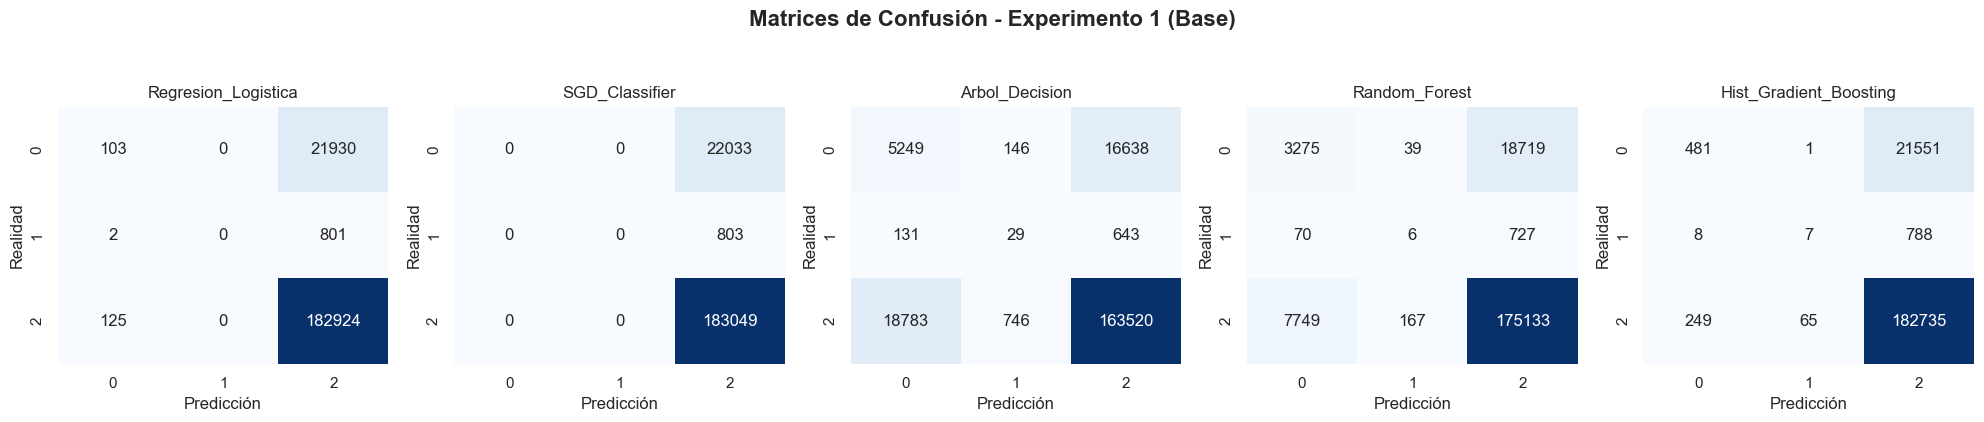

In [122]:
# ==========================================
# MATRICES EXP 1: Default + Sin Balanceo
# ==========================================
graficar_matrices(modelos_exp1, X_test, y_test, "Experimento 1 (Base)")

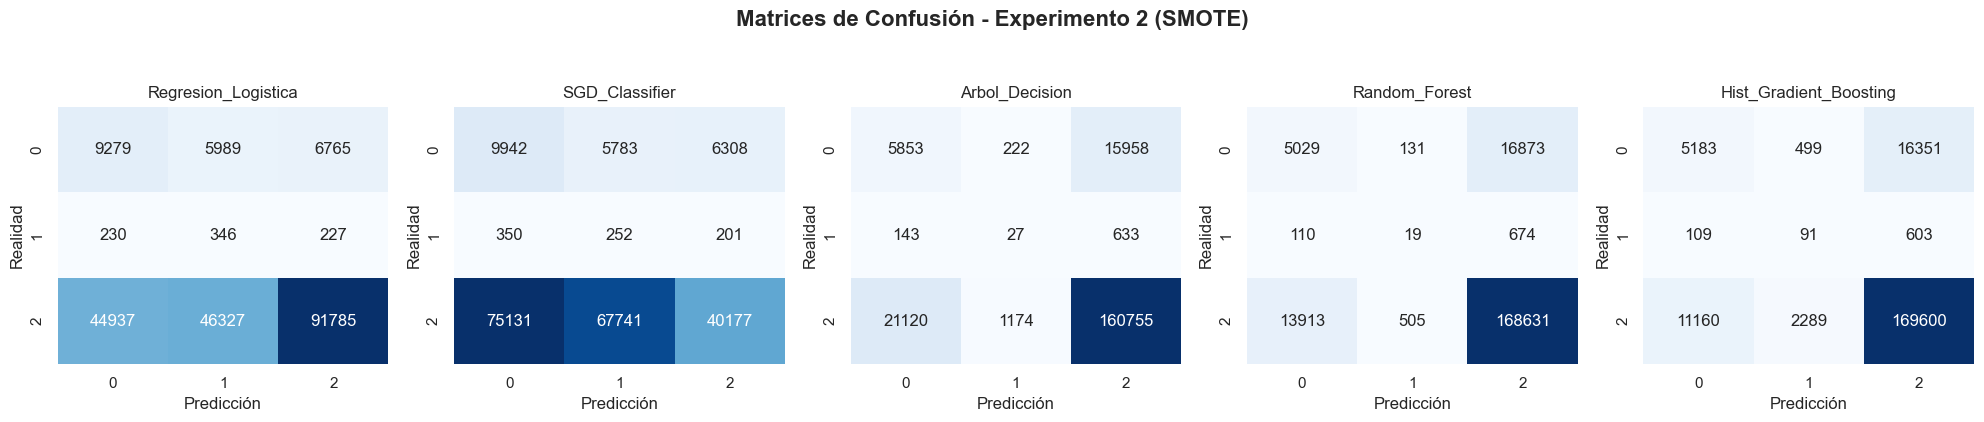

In [123]:
# ==========================================
# MATRICES EXP 2: Default + SMOTE
# ==========================================
graficar_matrices(modelos_exp2, X_test, y_test, "Experimento 2 (SMOTE)")

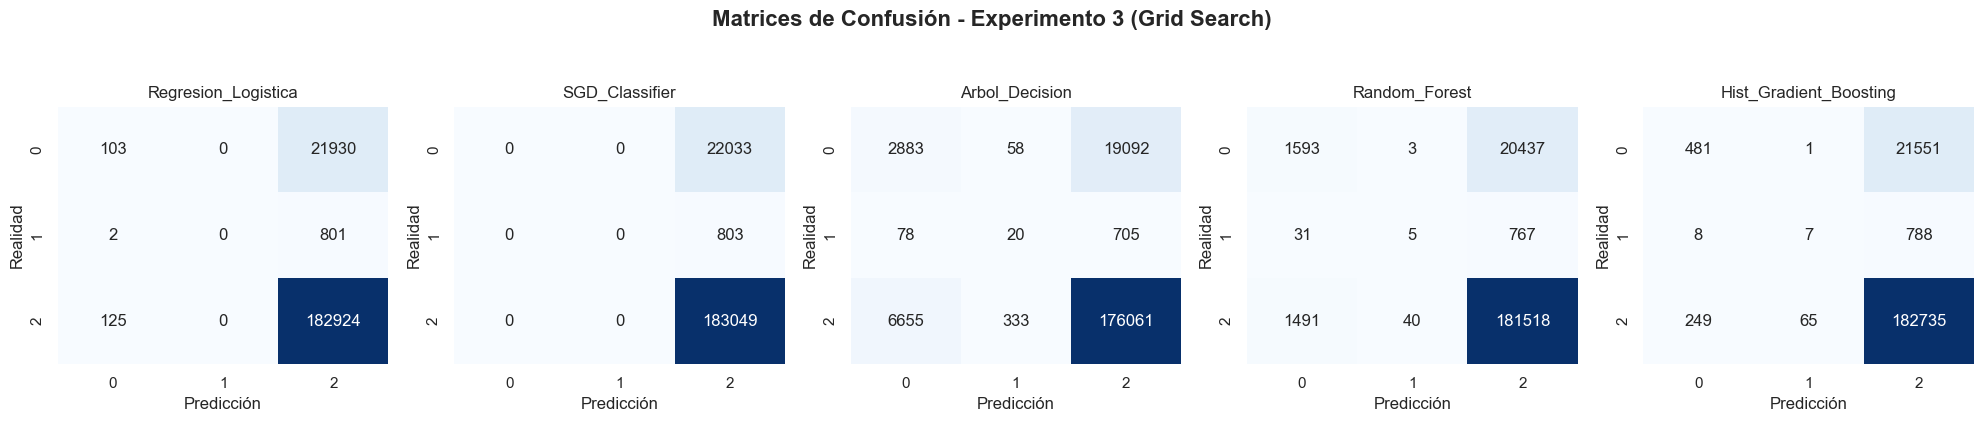

In [124]:
# ==========================================
# MATRICES EXP 3: Grid Search + Sin Balanceo
# ==========================================
graficar_matrices(modelos_exp3, X_test, y_test, "Experimento 3 (Grid Search)")

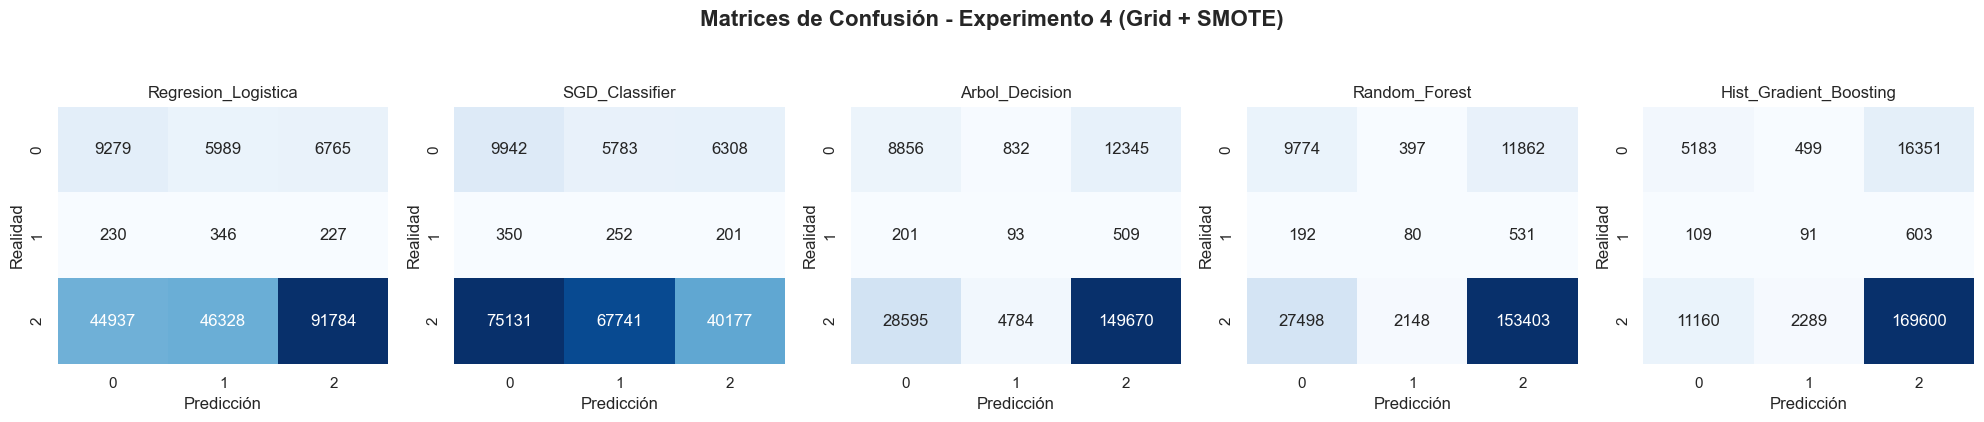

In [125]:
# ==========================================
# MATRICES EXP 4: Grid Search + SMOTE
# ==========================================
graficar_matrices(modelos_exp4, X_test, y_test, "Experimento 4 (Grid + SMOTE)")

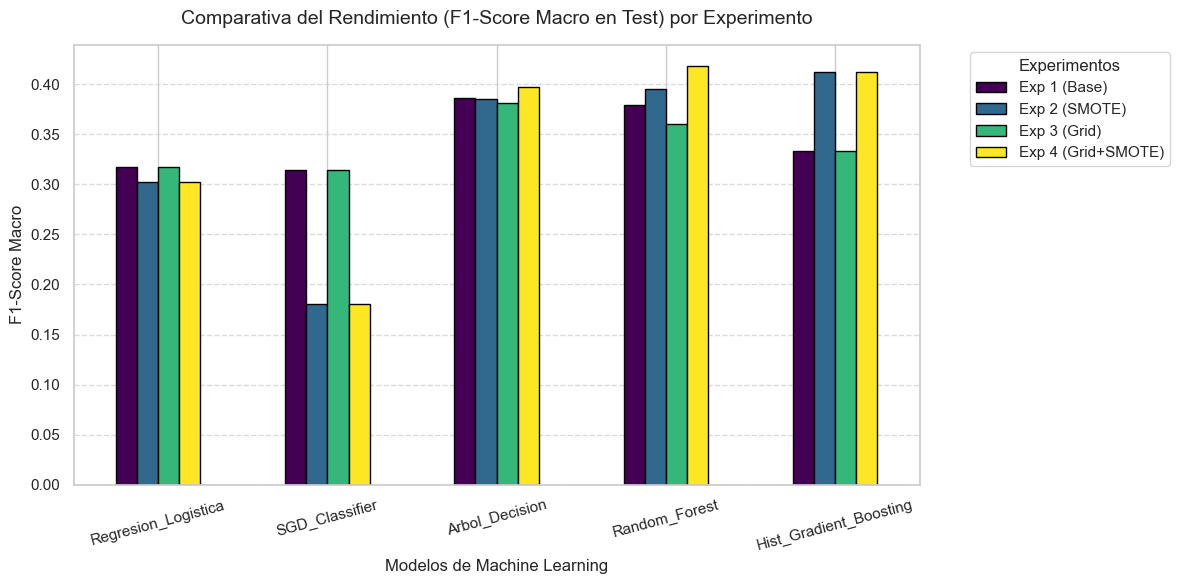

In [119]:
# ==========================================
# CELDA 3: Gráfico Comparativo Final
# ==========================================

# Consolidamos el F1 Test de todos los experimentos
df_grafico = pd.DataFrame({
    'Modelo': df_exp1['Modelo'],
    'Exp 1 (Base)': df_exp1['F1 Test'],
    'Exp 2 (SMOTE)': df_exp2['F1 Test'],
    'Exp 3 (Grid)': df_exp3['F1 Test'],
    'Exp 4 (Grid+SMOTE)': df_exp4['F1 Test']
})

# Graficamos
df_grafico.set_index('Modelo').plot(
    kind='bar', figsize=(12, 6), colormap='viridis', edgecolor='black'
)

plt.title('Comparativa del Rendimiento (F1-Score Macro en Test) por Experimento', fontsize=14, pad=15)
plt.xlabel('Modelos de Machine Learning', fontsize=12)
plt.ylabel('F1-Score Macro', fontsize=12)
plt.xticks(rotation=15)
plt.legend(title='Experimentos', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()